## reproducing Fig. 4 of Kitade and Kataoka 2026

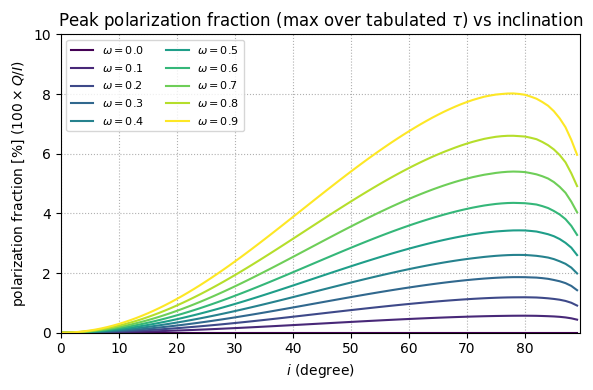

In [2]:
from emergentintensity import INTERP_TABLES, setup_tables
import numpy as np
import matplotlib.pyplot as plt

# ---- ensure tables ----
if INTERP_TABLES is None:
    setup_tables()

tau_grid   = np.asarray(INTERP_TABLES["tau_grid"], dtype=float)
omega_arr  = np.asarray(INTERP_TABLES["omega_grid"], dtype=float)  # use table grid
per_tau    = INTERP_TABLES["per_tau"]

# ---- inclination grid (exclude 90 deg) ----
# 0.5 deg steps but stop at 89.5 to avoid mu=0
inc_vals = np.arange(0.0, 90.0, 1.0)   # 0.0 ... 89.0
mu_vals  = np.cos(np.deg2rad(inc_vals))

# ---- compute peak 100*(Q/I) over tau, for each omega ----
PF_peak = np.empty((len(omega_arr), len(mu_vals)), dtype=float)

for iw in range(len(omega_arr)):
    peak_vs_i = np.full(len(mu_vals), -np.inf, dtype=float)

    for kt in range(len(tau_grid)):
        rec = per_tau[kt]
        mu_grid = np.asarray(rec["mu_grid"], dtype=float)     # increasing
        I_mu = np.asarray(rec["I"][iw, :], dtype=float)
        Q_mu = np.asarray(rec["Q"][iw, :], dtype=float)

        # fast mu-interp for all inclinations at once (clipped at ends)
        I_i = np.interp(mu_vals, mu_grid, I_mu)
        Q_i = np.interp(mu_vals, mu_grid, Q_mu)

        pf_i = np.zeros_like(I_i)
        mask = (I_i != 0.0)
        pf_i[mask] = Q_i[mask] / I_i[mask]

        peak_vs_i = np.maximum(peak_vs_i, pf_i)

    PF_peak[iw, :] = 100.0 * peak_vs_i

# ---- plot ----
plt.figure(figsize=(6, 4))
colors = plt.cm.viridis(np.linspace(0.0, 1.0, len(omega_arr)))

for iw, (omega, c) in enumerate(zip(omega_arr, colors)):
    plt.plot(inc_vals, PF_peak[iw, :], color=c, label=fr"$\omega={omega:.1f}$")

plt.xlabel(r"$i$ (degree)")
plt.ylabel(r"polarization fraction [%] ($100\times Q/I$)")
plt.xlim(0.0, 89.5)
plt.ylim(0.0, 10.0)  # adjust if needed
plt.grid(True, ls=":")
plt.legend(ncol=2, fontsize=8, loc="best")
plt.title(r"Peak polarization fraction (max over tabulated $\tau$) vs inclination")
plt.tight_layout()
plt.show()